In [1]:
from utils_task2 import RedditLinkDataset

dataset = RedditLinkDataset(path="Reddit")
train_loader, val_loader, test_loader = dataset.get_link_loaders(batch_size=1024)

Caricamento del macro-grafo originale di Reddit...
Grafo originale: 232965 nodi, 114615892 archi
--> Grafo ridotto al 1.0%: 232965 nodi, 1146158 archi

--- STATISTICHE STRUTTURALI DEL GRAFO RIDOTTO ---
Archi positivi (Supervisione) in Train: 403246
Coppie totali (Pos+Neg) in Val: 115212
Coppie totali (Pos+Neg) in Test: 230426


In [2]:
#iperparametri
lr = 1e-4
num_epochs = 10

Tentativo GCN

In [3]:
import torch
from utils_task2 import GCNLinkPredictor
from utils_task2 import train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GCNLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GCN.pth",
    scaler=scaler,
)




Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4846 | Loss Val: 0.4995 | Val AUC-ROC: 0.9201 |Val AP: 0.9165 |Val Balanced Acc: 0.7508 |Val F1: 0.7938
--> Modello salvato con Loss Val Migliore: 0.4995


Epoca: 02/10 |Loss Train: 0.4362 | Loss Val: 0.4879 | Val AUC-ROC: 0.9289 |Val AP: 0.9282 |Val Balanced Acc: 0.7618 |Val F1: 0.8013
--> Modello salvato con Loss Val Migliore: 0.4879


Epoca: 03/10 |Loss Train: 0.4260 | Loss Val: 0.4861 | Val AUC-ROC: 0.9328 |Val AP: 0.9329 |Val Balanced Acc: 0.7632 |Val F1: 0.8025
--> Modello salvato con Loss Val Migliore: 0.4861


Epoca: 04/10 |Loss Train: 0.4198 | Loss Val: 0.4768 | Val AUC-ROC: 0.9335 |Val AP: 0.9354 |Val Balanced Acc: 0.7714 |Val F1: 0.8072
--> Modello salvato con Loss Val Migliore: 0.4768


...

Epoca: 06/10 |Loss Train: 0.4141 | Loss Val: 0.4684 | Val AUC-ROC: 0.9337 |Val AP: 0.9387 |Val Balanced Acc: 0.7698 |Val F1: 0.8053
--> Modello salvato con Loss Val Migliore: 0.4684


Epoca: 07/10 |Loss Train: 0.4122 | Loss Val: 0.4673 | Val AUC-ROC: 0.9329 |Val AP: 0.9387 |Val Balanced Acc: 0.7675 |Val F1: 0.8034
--> Modello salvato con Loss Val Migliore: 0.4673


Epoca: 08/10 |Loss Train: 0.4114 | Loss Val: 0.4644 | Val AUC-ROC: 0.9340 |Val AP: 0.9403 |Val Balanced Acc: 0.7739 |Val F1: 0.8079
--> Modello salvato con Loss Val Migliore: 0.4644


Epoca: 09/10 |Loss Train: 0.4100 | Loss Val: 0.4639 | Val AUC-ROC: 0.9339 |Val AP: 0.9402 |Val Balanced Acc: 0.7730 |Val F1: 0.8071
--> Modello salvato con Loss Val Migliore: 0.4639


Epoca: 10/10 |Loss Train: 0.4090 | Loss Val: 0.4611 | Val AUC-ROC: 0.9328 |Val AP: 0.9401 |Val Balanced Acc: 0.7739 |Val F1: 0.8072
--> Modello salvato con Loss Val Migliore: 0.4611


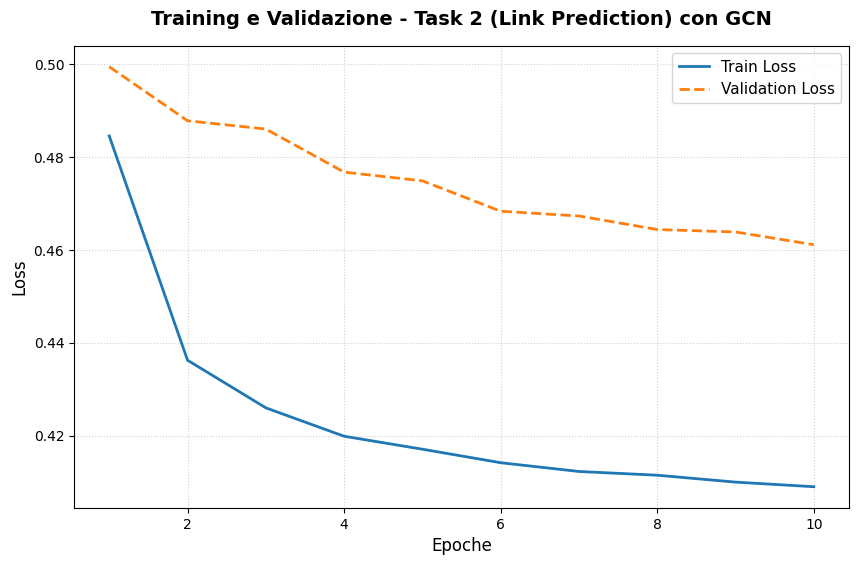

In [4]:
from utils_task2 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GCN")

In [5]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GCN")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GCN
-> Test Loss: 0.4607
-> Area Under the ROC Curve (AUC-ROC): 0.9392
-> Average Precision (AP Score): 0.9432
-> Balanced Accuracy: 0.7821
-> F1 Score: 0.8141


In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo SAGEConv

In [6]:
import torch
from utils_task2 import SAGEConvLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = SAGEConvLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_SAGE.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4640 | Loss Val: 0.4831 | Val AUC-ROC: 0.9045 |Val AP: 0.9195 |Val Balanced Acc: 0.7580 |Val F1: 0.7901
--> Modello salvato con Loss Val Migliore: 0.4831


Epoca: 02/10 |Loss Train: 0.4155 | Loss Val: 0.4717 | Val AUC-ROC: 0.9068 |Val AP: 0.9254 |Val Balanced Acc: 0.7569 |Val F1: 0.7888
--> Modello salvato con Loss Val Migliore: 0.4717


Epoca: 03/10 |Loss Train: 0.4057 | Loss Val: 0.4676 | Val AUC-ROC: 0.9068 |Val AP: 0.9287 |Val Balanced Acc: 0.7555 |Val F1: 0.7877
--> Modello salvato con Loss Val Migliore: 0.4676


Epoca: 04/10 |Loss Train: 0.4005 | Loss Val: 0.4642 | Val AUC-ROC: 0.9067 |Val AP: 0.9295 |Val Balanced Acc: 0.7553 |Val F1: 0.7873
--> Modello salvato con Loss Val Migliore: 0.4642


...

Epoca: 06/10 |Loss Train: 0.3955 | Loss Val: 0.4615 | Val AUC-ROC: 0.9081 |Val AP: 0.9313 |Val Balanced Acc: 0.7508 |Val F1: 0.7842
--> Modello salvato con Loss Val Migliore: 0.4615


Epoca: 07/10 |Loss Train: 0.3940 | Loss Val: 0.4619 | Val AUC-ROC: 0.9059 |Val AP: 0.9305 |Val Balanced Acc: 0.7451 |Val F1: 0.7800
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 08/10 |Loss Train: 0.3935 | Loss Val: 0.4603 | Val AUC-ROC: 0.9080 |Val AP: 0.9323 |Val Balanced Acc: 0.7497 |Val F1: 0.7835
--> Modello salvato con Loss Val Migliore: 0.4603


Epoca: 09/10 |Loss Train: 0.3923 | Loss Val: 0.4596 | Val AUC-ROC: 0.9092 |Val AP: 0.9324 |Val Balanced Acc: 0.7527 |Val F1: 0.7857
--> Modello salvato con Loss Val Migliore: 0.4596


Epoca: 10/10 |Loss Train: 0.3913 | Loss Val: 0.4595 | Val AUC-ROC: 0.9079 |Val AP: 0.9325 |Val Balanced Acc: 0.7477 |Val F1: 0.7820
--> Modello salvato con Loss Val Migliore: 0.4595


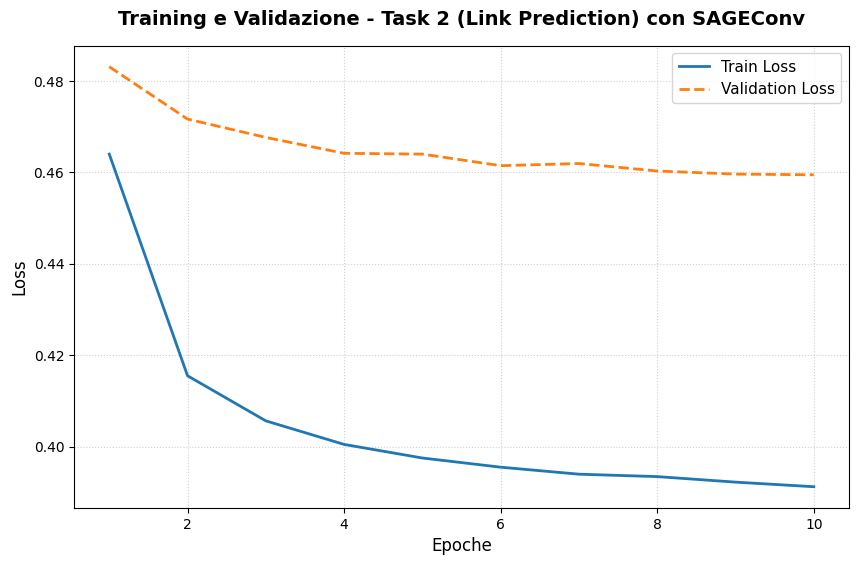

In [7]:
from utils_task2 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con SAGEConv")

In [8]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 SAGEConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 SAGEConv
-> Test Loss: 0.4527
-> Area Under the ROC Curve (AUC-ROC): 0.9194
-> Average Precision (AP Score): 0.9393
-> Balanced Accuracy: 0.7606
-> F1 Score: 0.7933


In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo GAT

In [9]:
import torch
from utils_task2 import GATLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GATLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GAT.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.5232 | Loss Val: 0.5144 | Val AUC-ROC: 0.8952 |Val AP: 0.8970 |Val Balanced Acc: 0.7344 |Val F1: 0.7790
--> Modello salvato con Loss Val Migliore: 0.5144


Epoca: 02/10 |Loss Train: 0.4416 | Loss Val: 0.5000 | Val AUC-ROC: 0.9048 |Val AP: 0.9102 |Val Balanced Acc: 0.7425 |Val F1: 0.7838
--> Modello salvato con Loss Val Migliore: 0.5000


Epoca: 03/10 |Loss Train: 0.4294 | Loss Val: 0.4914 | Val AUC-ROC: 0.9117 |Val AP: 0.9203 |Val Balanced Acc: 0.7455 |Val F1: 0.7862
--> Modello salvato con Loss Val Migliore: 0.4914


Epoca: 04/10 |Loss Train: 0.4215 | Loss Val: 0.4886 | Val AUC-ROC: 0.9167 |Val AP: 0.9259 |Val Balanced Acc: 0.7475 |Val F1: 0.7877
--> Modello salvato con Loss Val Migliore: 0.4886


...

Epoca: 06/10 |Loss Train: 0.4136 | Loss Val: 0.4712 | Val AUC-ROC: 0.9192 |Val AP: 0.9309 |Val Balanced Acc: 0.7581 |Val F1: 0.7938
--> Modello salvato con Loss Val Migliore: 0.4712


Epoca: 07/10 |Loss Train: 0.4109 | Loss Val: 0.4689 | Val AUC-ROC: 0.9211 |Val AP: 0.9331 |Val Balanced Acc: 0.7603 |Val F1: 0.7955
--> Modello salvato con Loss Val Migliore: 0.4689


Epoca: 08/10 |Loss Train: 0.4087 | Loss Val: 0.4665 | Val AUC-ROC: 0.9238 |Val AP: 0.9361 |Val Balanced Acc: 0.7586 |Val F1: 0.7948
--> Modello salvato con Loss Val Migliore: 0.4665


Epoca: 09/10 |Loss Train: 0.4065 | Loss Val: 0.4647 | Val AUC-ROC: 0.9240 |Val AP: 0.9363 |Val Balanced Acc: 0.7619 |Val F1: 0.7968
--> Modello salvato con Loss Val Migliore: 0.4647


Epoca: 10/10 |Loss Train: 0.4059 | Loss Val: 0.4619 | Val AUC-ROC: 0.9249 |Val AP: 0.9373 |Val Balanced Acc: 0.7653 |Val F1: 0.7991
--> Modello salvato con Loss Val Migliore: 0.4619


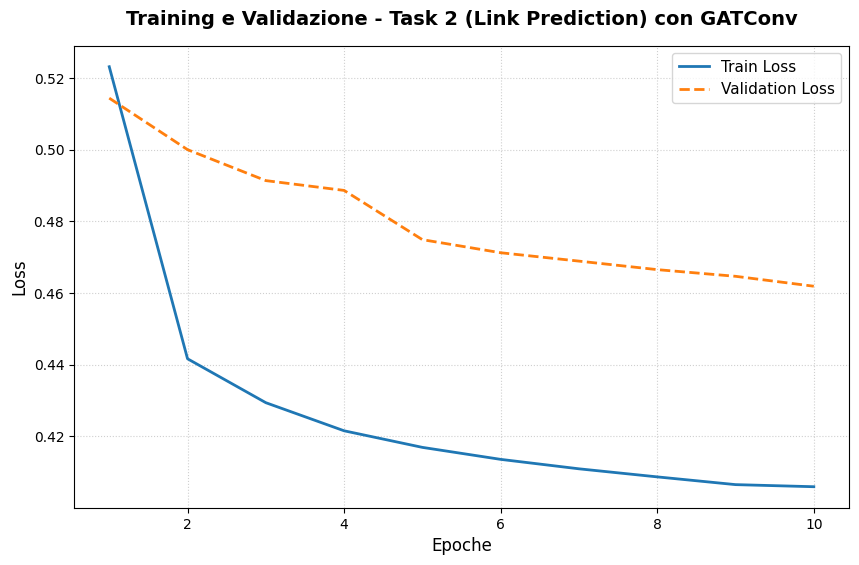

In [10]:
from utils_task2 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GATConv")

In [11]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GATConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GATConv
-> Test Loss: 0.4567
-> Area Under the ROC Curve (AUC-ROC): 0.9335
-> Average Precision (AP Score): 0.9425
-> Balanced Accuracy: 0.7751
-> F1 Score: 0.8074


In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()